# Chapter 14: Quantum Noise

--

**Prerequisites:**
- See `Chapter02_QuantumSoftware.ipynb` for installation instructions


In [2]:
# Setup and imports
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
from Chapter08_QuantumGates_functions import simulate_statevector, simulate_measurements #type: ignore
from qiskit_aer.noise import NoiseModel, depolarizing_error
from Chapter13_MatrixEncoding_functions import (LCU_fTAx)


## Basic Circuit: 
### Ideal state vector

<IPython.core.display.Latex object>

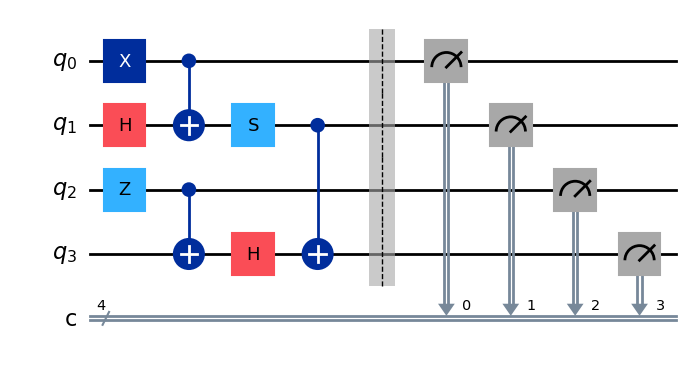

In [3]:
circuit = QuantumCircuit(4, 4) 
circuit.x(0) 
circuit.h(1) 
circuit.z(2) 
circuit.cx(0,1)
circuit.s(1)
circuit.cx(2,3)
circuit.h(3)
circuit.cx(1,3)
circuit.barrier()
psi = Statevector(circuit)
display(psi.draw('latex'))
circuit.measure([0,1,2,3], [0,1,2,3]) 
display(circuit.draw('mpl'))

### Statistical (measurement) error

In [4]:
nShots = 1000
circuit_clean = deepcopy(circuit)  # save original once
circuit_ready = circuit_clean.decompose(reps=3)
circuit_transpiled = transpile(circuit_ready, AerSimulator())
counts = simulate_measurements(circuit_transpiled, shots=nShots, transpiled=True)
print('Counts:',counts)
print('p_1011:', counts.get('1011', 0) / nShots)

Counts: {'0001': 258, '1001': 263, '0011': 251, '1011': 228}
p_1011: 0.228


### Statistical error vs. shots

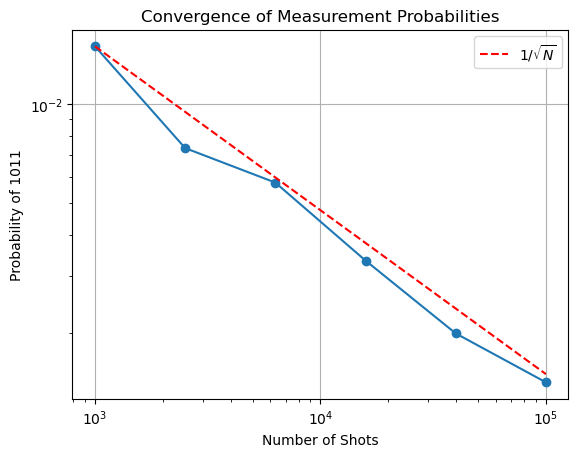

In [9]:
shots_list = np.logspace(3, 5, 6, dtype=int) # from 10^3 to 10^5 shots
err = []
std_err = []
nAttempts = 100

# Prepare circuit ONCE
simulator = AerSimulator()
circuit_clean = deepcopy(circuit)
circuit_ready = circuit_clean.decompose(reps=3)
circuit_transpiled = transpile(circuit_ready, simulator)

for shots in shots_list:
    p_list = []
    for _ in range(nAttempts):
        job = simulator.run(circuit_transpiled, shots=shots)
        counts = job.result().get_counts()
        p_list.append(counts.get('1011', 0) / shots)
    
    p_arr = np.array(p_list)
    err.append(np.std(p_arr))   # ← std, not |mean - 0.25|
    std_err.append(np.std(p_arr) / np.sqrt(nAttempts))
plt.loglog(shots_list, err, marker='o')
# Reference line: C/sqrt(N)
C = err[0] * np.sqrt(shots_list[0])
ref = [C / np.sqrt(s) for s in shots_list]
plt.loglog(shots_list, ref, 'r--', label=r'$1/\sqrt{N}$')

plt.legend()
plt.xlabel('Number of Shots')
plt.ylabel('Probability of 1011')
plt.title('Convergence of Measurement Probabilities')
plt.grid()
plt.show()

## f^T A x: Impact of noise

In [29]:
A = np.array([
    [1, 0, 0, 0.5],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0.5, 0, 0, 1]
], dtype=float)

x = np.array([0.6, 0.8, 0, 0], dtype=complex)

f = np.array([1, 1, 1, 1], dtype=complex)
f = f / np.linalg.norm(f)  # Normalize f to unit length

expected_output = f @ A @ x
print("Classical output        :", np.round(np.real_if_close(expected_output), 4))

shots = 10000
[result_ideal, qc, metadata_ideal] = LCU_fTAx(f, A, x, shots=shots)
print("Quantum output (No noise):", np.round(np.real_if_close(result_ideal), 4))
print("Success_prob (No noise):", metadata_ideal['success_prob'])

noise_model = NoiseModel()
error_1q = depolarizing_error(0.001, 1) # 1-qubit gates
error_2q = depolarizing_error( 0.01, 2) # 2-qubit gates

single_qubit_gates = ['u1', 'u2', 'u3', 'u',   # generic unitaries
                      'h', 'x', 'y', 'z',        # Pauli + Hadamard
                      's', 'sdg', 't', 'tdg',    # phase gates
                      'rx', 'ry', 'rz',           # rotation gates
                      'p', 'sx', 'sxdg']          # other common gates
noise_model.add_all_qubit_quantum_error(error_1q,single_qubit_gates)

two_qubit_gates = ['cx', 'cz', 'cy',        # controlled Pauli
                   'ch',                      # controlled Hadamard
                   'crx', 'cry', 'crz',      # controlled rotations
                   'cp', 'cu',               # controlled phase/unitary
                   'swap', 'iswap',          # swap gates
                   'ecr', 'rzz', 'rxx']      # native gates on some hardware
noise_model.add_all_qubit_quantum_error(error_2q, two_qubit_gates)

[result_noisy, qc, metadata_noisy] = LCU_fTAx(f, A, x, shots=shots, noise_model=noise_model)
print("Quantum output (With noise):", np.round(np.real_if_close(result_noisy), 4))
print("Success_prob (With noise):", metadata_noisy['success_prob'])

Classical output        : 0.85
Quantum output (No noise): 0.8425
Success_prob (No noise): 0.4735
Quantum output (With noise): 0.7709
Success_prob (With noise): 0.4448
